# Building and Using a DiscountCurve

Build a curve object directly from a vector of times and discount factors

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from financepy.utils.date import Date
from financepy.market.curves.interpolator import interpolate, InterpTypes
from financepy.market.curves.discount_curve import DiscountCurve

## Building the Discount Curve

Set the start date that anchors the curve

In [3]:
start_dt = Date(1, 1, 2018)

Set a vector of times out to 10 years

In [4]:
times = np.linspace(0, 10.0, 5)

In [5]:
dates = start_dt.add_years(times)

In [6]:
print(dates)

[01-JAN-2018, 01-JUL-2020, 01-JAN-2023, 01-JUL-2025, 01-JAN-2028]


Now generate the vector of discount factors at a continuous rate of 5%

In [7]:
rates = np.zeros(5)
rates[0] = 0.0475
rates[1] = 0.0500
rates[2] = 0.0525
rates[3] = 0.0550
rates[4] = 0.0575
dfs = np.exp(-rates * times)

We now construct the Discount Curve

In [8]:
curve = DiscountCurve(start_dt,dates,dfs, InterpTypes.FLAT_FWD_RATES)

## Calculating Instantaneous Forward Rates

First look at monthly time steps

In [9]:
years = np.linspace(1,10,120)
dates = start_dt.add_years(years)
fwds = curve.fwd_rate_inst(dates)

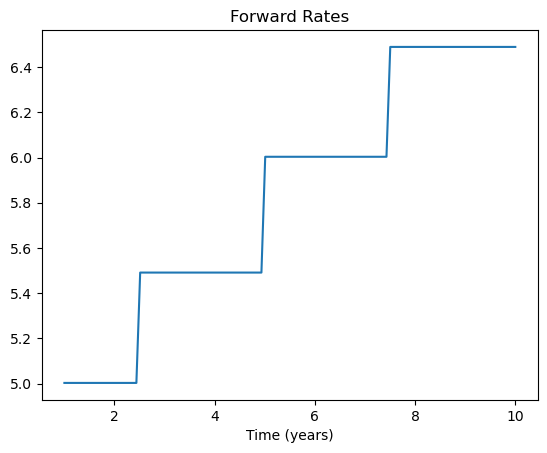

In [10]:
plt.title("Forward Rates")
plt.xlabel("Time (years)")
plt.plot(years, fwds*100);

We see that these are piecewise flat as the interpolation imposes.

## Money Market Forward Rates

In [11]:
years = np.linspace(1,10,120)
start_dts = start_dt.add_years(years)
tenor = "3M"
fwds = curve.fwd_rate(dates, tenor)

In [12]:
type(fwds), type(years)

(numpy.ndarray, numpy.ndarray)

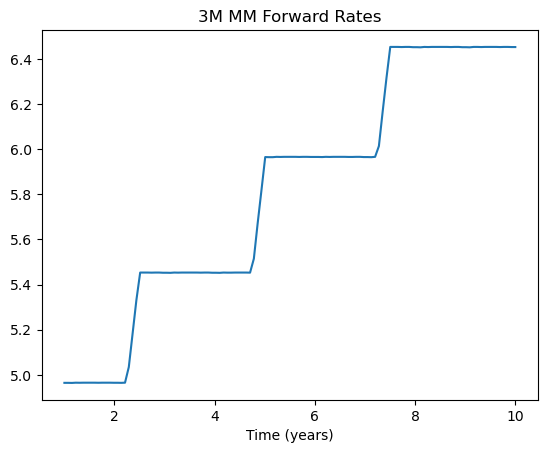

In [13]:
plt.title("3M MM Forward Rates")
plt.xlabel("Time (years)")
plt.plot(years, fwds*100);

## Calculating Swap Rates

In [14]:
swap_rates = curve.swap_rate(start_dt.add_days(0), dates)

Text(0.5, 1.0, 'Swap Rates')

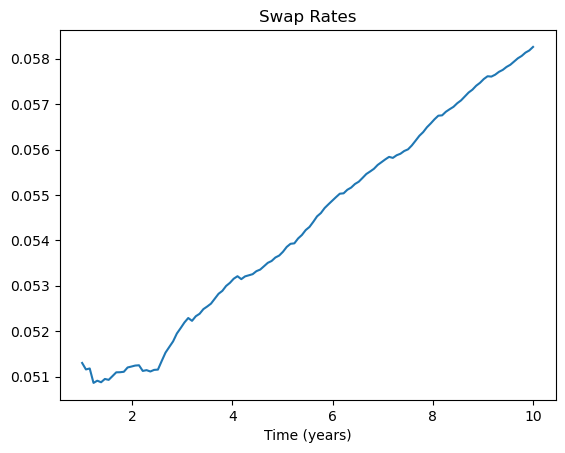

In [15]:
plt.xlabel("Time (years)")
plt.plot(years, swap_rates);
plt.title("Swap Rates")

TODO: REVISIT AND CHECK

Copyright (c) 2020 Dominic O'Kane